# Finer lookbacks and the rebalance day

Every trend result so far looked back a whole number of weeks and traded at the Sunday close. Two things were never varied. The lookback in days, and the day of the week the book rebalances.

This notebook varies both. The lookback runs over every day count from 5 to 35, and the weekly rebalance moves to each of the seven days. If the 4-week result is real it should hold at 26 and 30 days as well as 28, and on a Wednesday as well as a Sunday. If it only appears at 28 days on a Sunday it is a lucky cell.

It is a robustness check, not a search. No cell is picked as a winner. The whole surface is the result.

## Setup

Load the daily bars and funding, and take daily log returns with the same cleaning the weekly panel uses. The trailing return over $D$ days is the sum of the last $D$ daily returns, read at the close of the rebalance day. The book is otherwise unchanged. Inverse volatility sizing on coins trading at least \$10M a day, held a week, net of the provisional cost and funding.

The market book takes one sign from the average liquid coin's trailing $D$-day return and holds the whole basket long or short.

In [ ]:
import warnings
from book import Book, halves, sharpe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import gate, panel, stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

bars, prints = stream.universe('2020-01-01', '2026-09-01', log=lambda *a, **k: None)
drop = stream.non_crypto()
bars, prints = bars[~bars.symbol.isin(drop)], prints[~prints.symbol.isin(drop)]
close = bars.pivot(index='day', columns='symbol', values='close')
volume = bars.pivot(index='day', columns='symbol', values='volume')
daily = panel.daily_returns(close, volume > 0)

DAYS = list(range(, 36))
WEEKS = {'Sun': 'W-SUN', 'Mon': 'W-MON', 'Tue': 'W-TUE', 'Wed': 'W-WED', 'Thu': 'W-THU', 'Fri': 'W-FRI', 'Sat': 'W-SAT'}
trail = {D: daily.rolling(D, min_periods=int(np.ceil(D * 5 / 7))).sum() for D in DAYS}

def coin_signal(b, D, week):
    """Sign of each coin's trailing D-day return at the rebalance close."""
    return np.sign(trail[D].resample(week).last().reindex(b.W.index))

def market_trail(b, D, week):
    """The average liquid coin's trailing D-day return at the rebalance close."""
    liquid = b.LIQ.reindex(daily.index, method='bfill') >= 1e7
    return daily.where(liquid).mean(axis=1).rolling(D, min_periods=D).sum().resample(week).last().reindex(b.W.index)

def coin_net(b, D, week):
    return b.run(b.sized(coin_signal(b, D, week).shift(1))).net

def market_net(b, D, week):
    return b.run(b.basket().mul(np.sign(market_trail(b, D, week)).shift(1), axis=0)).net

books = {name: Book(panel.build(bars, prints, week=rule)) for name, rule in WEEKS.items()}
sun = books['Sun']
print(f'daily panel {daily.shape}  {daily.index.min().date()} .. {daily.index.max().date()}   weeks {len(sun.W)}')

daily panel (2435, 681)  2020-01-01 .. 2026-08-31   weeks 349


## Checking against the weekly book

A lookback of 7, 14, 21, 28 or 35 days on a Sunday is the weekly book at 1 to 5 weeks, built a different way. The two should agree. Where they do not, list the weeks the sign differs and what each week cost.

In [2]:
rows = []
for L in (1, 2, 3, 4, 5):
    rows.append({'weeks': L, 'per coin, weekly': sharpe(sun.run(sun.per_coin(L)).net), 'per coin, days': sharpe(coin_net(sun, 7 * L, 'W-SUN')),
                 'market, weekly': sharpe(sun.run(sun.market(L)).net), 'market, days': sharpe(market_net(sun, 7 * L, 'W-SUN'))})
print(pd.DataFrame(rows).set_index('weeks').round(2))

weekly_sum = sun.market_ret().rolling(4, min_periods=4).sum()
daily_sum = market_trail(sun, 28, 'W-SUN')
differs = (np.sign(weekly_sum) != np.sign(daily_sum)) & weekly_sum.notna() & daily_sum.notna()
gap = (sun.run(sun.market(4)).net - market_net(sun, 28, 'W-SUN')).dropna()
print(f'\nmarket book at 4 weeks, sign differs in {differs.sum()} of {(weekly_sum.notna() & daily_sum.notna()).sum()} weeks')
print(pd.DataFrame({'trailing return, weekly build': weekly_sum, 'trailing return, daily build': daily_sum})[differs].round(4))
print('\nnet return gap in the week after, weekly build minus daily build')
print(gap[gap.abs() > 0.01].round(3))

       per coin, weekly  per coin, days  market, weekly  market, days
weeks                                                                
1                  0.57            0.57            0.42          0.42
2                  0.43            0.43            0.46          0.48
3                  0.18            0.18            0.02          0.02
4                  0.85            0.85            0.80          0.61
5                  0.75            0.75            0.43          0.55

market book at 4 weeks, sign differs in 2 of 340 weeks
                           trailing return, weekly build  \
day                                                        
2021-05-16 00:00:00+00:00                        -0.0001   
2025-08-31 00:00:00+00:00                        -0.0021   

                           trailing return, daily build  
day                                                      
2021-05-16 00:00:00+00:00                        0.0011  
2025-08-31 00:00:00+00:00              

The per coin book matches exactly at every lookback, so the daily build is the same book.

The market book does not match at 4 weeks, 0.61 against 0.80, and the reason is one week. The two builds average coins slightly differently, and their signs differ in 2 of 340 weeks, both where the market's trailing return sat within 0.3% of zero. One of those is 16 May 2021. The weekly build read $-0.0001$ and went short. The daily build read $+0.0011$ and went long. The next week was the May 2021 crash, worth 0.97 between them.

So a fifth of the market book's Sharpe rests on the sign of a number within 0.1% of zero. The market book is one bet a week, and its record through the May 2021 crash was a coin flip.

## The surface

Net Sharpe for every lookback from 5 to 35 days on every rebalance day, 217 cells a book. The cells are close copies of each other, a lookback one day longer or a rebalance one day later changes few positions, so the spread between neighbours is a direct read on how much of any one cell is noise.

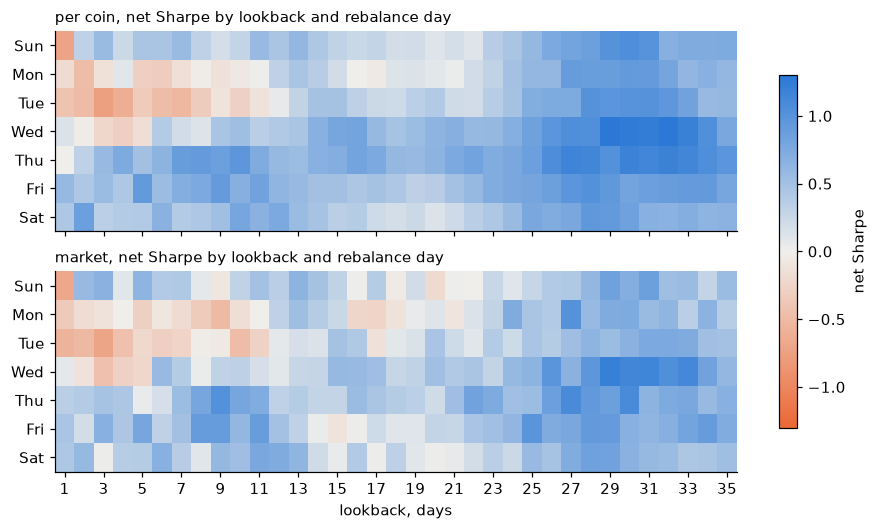

per coin   cells positive 0.89   median cell 0.57
market   cells positive 0.85   median cell 0.42

per coin, selected lookbacks
       Sun   Mon   Tue   Wed   Thu   Fri   Sat
days                                          
7     0.57 -0.14 -0.53  0.20  0.88  0.70  0.39
14    0.43  0.36  0.48  0.68  0.67  0.50  0.48
21    0.18  0.03  0.21  0.69  0.75  0.50  0.21
26    0.76  0.60  0.74  0.97  1.06  0.86  0.72
27    0.80  0.90  0.75  1.05  1.16  0.97  0.78
28    0.85  0.88  1.01  1.04  1.14  1.02  0.94
29    1.01  0.88  0.97  1.28  1.02  0.94  0.92
30    1.05  0.92  1.00  1.25  1.18  0.80  0.85
31    1.00  0.91  1.01  1.23  1.15  0.87  0.68
35    0.75  0.61  0.59  0.78  0.97  0.78  0.65


In [6]:
coin = pd.DataFrame({name: {D: sharpe(coin_net(b, D, WEEKS[name])) for D in DAYS} for name, b in books.items()})
market = pd.DataFrame({name: {D: sharpe(market_net(b, D, WEEKS[name])) for D in DAYS} for name, b in books.items()})
coin.index.name = market.index.name = 'days'

cmap = LinearSegmentedColormap.from_list('div', [ORANGE, '#f0efec', BLUE])
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
for ax, (title, grid) in zip(axes, [('per coin', coin), ('market', market)]):
    im = ax.imshow(grid.T.values, aspect='auto', cmap=cmap, norm=TwoSlopeNorm(0, -1.3, 1.3))
    ax.set_yticks(range(7)); ax.set_yticklabels(grid.columns); ax.grid(False)
    ax.set_title(f'{title}, net Sharpe by lookback and rebalance day', loc='left', fontsize=10)
axes[1].set_xticks(range(0, len(DAYS), 2)); axes[1].set_xticklabels(DAYS[::2]); axes[1].set_xlabel('lookback, days')
fig.colorbar(im, ax=axes, shrink=0.8, label='net Sharpe')
plt.show()

for title, grid in [('per coin', coin), ('market', market)]:
    print(f'{title}   cells positive {(grid > 0).mean().mean():.2f}   median cell {np.median(grid.values):.2f}')
print('\nper coin, selected lookbacks')
print(coin.loc[[7, 14, 21, 26, 27, 28, 29, 30, 31, 35]].round(2))

Two regions, and they behave differently.

From 25 to 33 days the per coin book is positive on every rebalance day at every lookback, from 0.59 to 1.29. At 28 days it makes 0.85 to 1.14 across the seven days, and Sunday is the lowest of them. The 4-week Sunday book was not a lucky cell. It was the weakest cell of a solid block.

Below about two weeks the result depends on the day. A 7-day lookback makes 0.88 rebalanced on a Thursday and $-0.53$ on a Tuesday. Monday and Tuesday are negative at nearly every lookback under 12 days. A signal that flips sign with the rebalance day is not a signal, so the 1-week book's 0.57 on Sunday carries no weight.

The market book shows the same block, thinner. At 28 days it makes 0.57 to 0.96 across the days, and it is positive on every day from 27 to 33.

## Averaged over the rebalance day

The day of the week is not a setting anyone has a reason to choose. Averaging each lookback over the seven days removes it, and the range across days shows the noise left in a single cell.

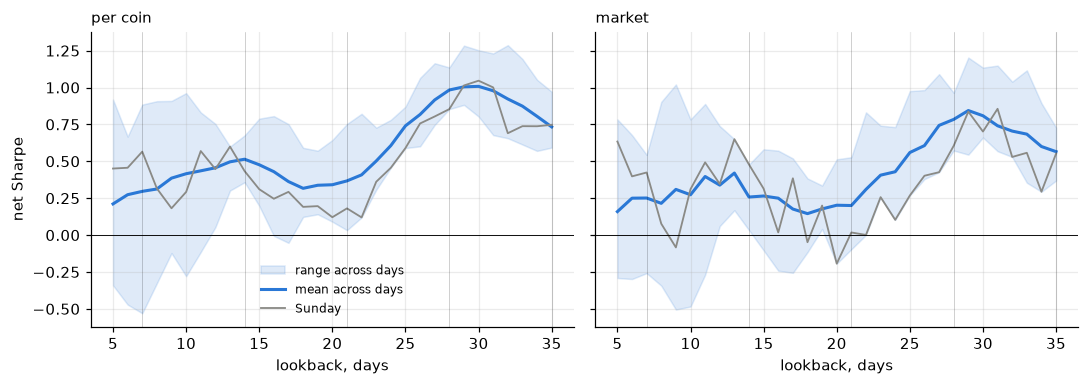

      per coin mean  per coin min  per coin max  market mean  market min  \
days                                                                       
7              0.30         -0.53          0.88         0.25       -0.26   
10             0.42         -0.28          0.96         0.27       -0.48   
14             0.51          0.36          0.68         0.26        0.03   
17             0.36         -0.05          0.75         0.18       -0.26   
19             0.34          0.14          0.57         0.18        0.04   
21             0.37          0.03          0.75         0.20       -0.10   
23             0.50          0.31          0.73         0.41        0.26   
25             0.74          0.59          0.87         0.56        0.27   
27             0.92          0.75          1.16         0.74        0.43   
28             0.98          0.85          1.14         0.78        0.57   
29             1.00          0.88          1.28         0.84        0.55   
30          

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (title, grid) in zip(axes, [('per coin', coin), ('market', market)]):
    ax.fill_between(DAYS, grid.min(axis=1), grid.max(axis=1), color=BLUE, alpha=0.15, label='range across days')
    ax.plot(DAYS, grid.mean(axis=1), color=BLUE, label='mean across days')
    ax.plot(DAYS, grid['Sun'], color=GREY, lw=1.2, label='Sunday')
    ax.axhline(0, color='k', lw=0.6)
    for d in (7, 14, 21, 28, 35):
        ax.axvline(d, color='k', lw=0.4, alpha=0.3)
    ax.set_title(title, loc='left', fontsize=10); ax.set_xlabel('lookback, days')
axes[0].set_ylabel('net Sharpe'); axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({'per coin mean': coin.mean(axis=1), 'per coin min': coin.min(axis=1), 'per coin max': coin.max(axis=1),
                        'market mean': market.mean(axis=1), 'market min': market.min(axis=1), 'market max': market.max(axis=1)})
print(summary.loc[[7, 10, 14, 17, 19, 21, 23, 25, 27, 28, 29, 30, 31, 33, 35]].round(2))
print('\nmean over all lookbacks by rebalance day')
print(pd.DataFrame({'per coin': coin.mean(), 'market': market.mean()}).T.round(2))

Averaged over the rebalance day the per coin book has one smooth hump. It sits near 0.3 to 0.5 from 7 to 23 days, climbs from 24, peaks at 1.0 around 29 to 30 days, and eases to 0.73 by 35. Nothing is special about 28. The peak is a day or two past it.

The 3-week hole is a shallow dip, not a hole. At 21 days the mean is 0.37, against 0.51 at 14, and the range runs from 0.03 on a Monday to 0.75 on a Thursday. Sunday's 0.18 sits at the bottom of that range. The weekly grid showed a fourfold drop between 3 and 4 weeks. By the day, the surface rises steadily from 22 to 29.

The spread across days at one lookback is about 0.3 in the block and over 1.0 under two weeks. That is the size of the noise in any single cell, and it is larger than most of the differences the weekly grid was read on.

Thursday and Wednesday are the best rebalance days on average and Monday the worst, 0.85 against 0.33 per coin. That is seven close copies of one book, and it is not a reason to pick a day.

## The seven-slice book

Any single rebalance day is arbitrary. The book that removes the choice splits its capital into seven equal slices and rebalances one slice each day of the week. Every slice still holds for a week, so the trading is the same, but one seventh of the book refreshes its signal every day and no day decides the result.

To add the slices together their returns are put on one daily clock. A slice's price moves land on the day they happen. Its funding and its trading cost land on the last day of its week. The seven are averaged, and the daily total is summed into calendar weeks so the Sharpe reads on the same scale as every other book.

Sunday slice by day against the weekly book, largest weekly gap 0.00018



      seven-slice  mean of the seven days  Sunday  worst day  best day
days                                                                  
7            0.33                    0.30    0.57      -0.53      0.88
10           0.46                    0.42    0.29      -0.28      0.96
14           0.56                    0.51    0.43       0.36      0.68
17           0.39                    0.36    0.29      -0.05      0.75
21           0.39                    0.37    0.18       0.03      0.75
24           0.65                    0.61    0.46       0.46      0.78
26           0.86                    0.82    0.76       0.60      1.06
27           0.96                    0.92    0.80       0.75      1.16
28           1.02                    0.98    0.85       0.85      1.14
29           1.04                    1.00    1.01       0.88      1.28
30           1.04                    1.01    1.05       0.80      1.25
31           1.01                    0.98    1.00       0.68      1.23
32    

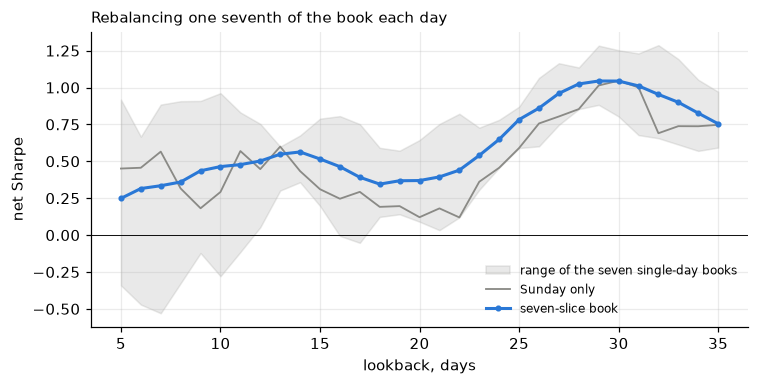

In [5]:
held = panel.held_returns(close, volume > 0).fillna(0.0)

def slice_daily(b, w):
    """One slice's net return by day, from its weekly weights."""
    r = b.run(w)
    by_day = b.hold(w).reindex(held.index, method='bfill').fillna(0.0)
    since_rebalance = held.groupby(b.W.index.searchsorted(held.index)).cumsum()
    gross = (by_day * (np.exp(since_rebalance) - np.exp(since_rebalance - held))).sum(axis=1)
    return gross.add((r.funding + r.cost).reindex(held.index).fillna(0.0), fill_value=0.0)

def seven_slice(D):
    """Weekly net return of the book rebalancing one seventh each day."""
    parts = [slice_daily(b, b.sized(coin_signal(b, D, WEEKS[name]).shift(1))) for name, b in books.items()]
    weekly = pd.concat(parts, axis=1).mean(axis=1).resample('W-SUN').sum()
    return weekly.loc[(weekly != 0).idxmax():]

check = slice_daily(sun, sun.sized(coin_signal(sun, 28, 'W-SUN').shift(1))).resample('W-SUN').sum()
ref = coin_net(sun, 28, 'W-SUN')
print(f'Sunday slice by day against the weekly book, largest weekly gap {(check.reindex(ref.index) - ref).abs().max():.5f}\n')

sliced = {D: seven_slice(D) for D in DAYS}
table = pd.DataFrame({'seven-slice': {D: sharpe(sliced[D]) for D in DAYS}, 'mean of the seven days': coin.mean(axis=1),
                      'Sunday': coin['Sun'], 'worst day': coin.min(axis=1), 'best day': coin.max(axis=1)})
table.index.name = 'days'
print(table.loc[[7, 10, 14, 17, 21, 24, 26, 27, 28, 29, 30, 31, 32, 33, 35]].round(2))

years = pd.DataFrame({f'{D} days': sliced[D].groupby(sliced[D].index.year).apply(sharpe) for D in (21, 28, 30)}).T
print('\nseven-slice book by year'); print(years.round(2))
for trials in (42, 74):
    prob, bar = gate.significance(sliced[28], trials)
    print(f'28 days against {trials} effective trials   luck bar {bar:.2f}   probability real {prob:.2f}')
early = {D: halves(sliced[D].index) for D in (28, 30)}
for D in (28, 30):
    print(f'{D} days   earlier weeks {sharpe(sliced[D][early[D]]):.2f}   later weeks {sharpe(sliced[D][~early[D]]):.2f}')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.fill_between(DAYS, coin.min(axis=1), coin.max(axis=1), color=GREY, alpha=0.18, label='range of the seven single-day books')
ax.plot(DAYS, coin['Sun'], color=GREY, lw=1.2, label='Sunday only')
ax.plot(DAYS, table['seven-slice'], color=BLUE, marker='o', ms=3, label='seven-slice book')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('lookback, days'); ax.set_ylabel('net Sharpe')
ax.set_title('Rebalancing one seventh of the book each day', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

With no rebalance day chosen, the 28-day book makes 1.02. That is above the 0.85 the lane has quoted, because Sunday was the weakest of the seven days. The curve is smooth, 0.86 at 26 days, a peak of 1.04 at 29 and 30, and 0.75 by 35.

The seven-slice Sharpe sits a little above the mean of the seven single-day books at every lookback, 1.02 against 0.98 at 28 days. Seven slices offset by a day are close copies but not identical, so averaging them removes a little noise.

It does not change the shape of the result. At 28 days the book is positive in every year from 2020 to 2025, 0.62 to 2.34, and loses 0.50 in 2026. The earlier weeks make 1.25 and the later weeks 0.66. At 21 days it makes 0.39 and loses in 2022, 2024 and 2026, so the dip near three weeks is real, only shallower than the Sunday book showed.

Against the lane's search the 28-day seven-slice book is real with probability 0.67 at 42 effective trials and 0.58 at 74. That is above the park line where the Sunday book sat just under it at 0.49. It is exploratory, built after the weekly result was known, so it parks at best.

## Does a clean trend continue better

The sign of the trailing return uses two prices, the start and the end of the window. A coin that climbed steadily and a coin that lurched up and down and happened to finish higher read the same. A stricter idea of a trend fits a straight line through the daily prices in the window and asks how well the line describes them.

$$\log P_d = a + b\,d + \varepsilon_d, \qquad R^2 = 1 - \frac{\sum_d \varepsilon_d^2}{\sum_d (\log P_d - \overline{\log P})^2}$$

- $\log P_d$ is the log price on day $d$ of the window.
- $b$ is the slope of the line, up or down a day.
- $\varepsilon_d$ is how far day $d$ sits off the line.
- $R^2$ is the share of the price's movement the line explains. Near 1 the prices hug the line, a clean trend. Near 0 the line is drawn through scatter.

For a fixed window the slope's t statistic is a function of $R^2$ alone, so how well the line fits and whether the slope is significant are one question. A wandering price fits a line well by accident, so $R^2$ is not judged against a fixed cut. Each week the liquid coins are sorted into thirds by it, choppy, middle and clean.

Three tests on the block from 25 to 33 days, every rebalance day. The plain sign inside each third, to see whether clean trends continue better. The sign of the slope against the sign of the trailing return, to see which reads direction better. And the slope's sign on the clean third alone, the stricter rule in full. Each is read over all weeks, the earlier three fifths and the later two fifths.

typical R2 cut points   choppy below 0.28   clean above 0.56
slope and trailing return agree on direction in 87% of coin-weeks

net Sharpe, mean over 9 lookbacks and 7 rebalance days
                          all  earlier  later
book                                         
plain sign               0.92     1.09   0.62
sign, choppy third       0.76     0.94   0.44
sign, middle third       0.86     1.01   0.60
sign, clean third        0.68     0.84   0.44
slope sign               0.68     0.86   0.38
slope sign, clean third  0.62     0.78   0.37

share of the 63 cells where
                                 all  earlier  later
clean third beats choppy third  0.44     0.43   0.54
clean third beats plain sign    0.05     0.06   0.22
slope sign beats plain sign     0.10     0.25   0.10


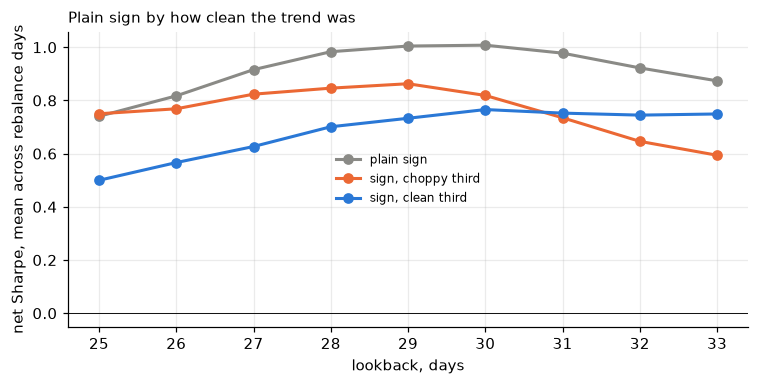

In [6]:
BLOCK = list(range(25, 34))
level = daily.fillna(0.0).cumsum()
clock = pd.Series(np.arange(len(level), dtype=float), index=level.index)
fit = {D: level.rolling(D).corr(clock).where(daily.notna().rolling(D).sum() >= int(np.ceil(D * 5 / 7))) for D in BLOCK}

def three(b, sig):
    net = b.run(b.sized(sig.shift(1))).net
    early = halves(net.index)
    return {'all': sharpe(net), 'earlier': sharpe(net[early]), 'later': sharpe(net[~early])}

rows, cuts, agree = [], [], []
for name, b in books.items():
    for D in BLOCK:
        ret = trail[D].resample(WEEKS[name]).last().reindex(b.W.index)
        corr = fit[D].resample(WEEKS[name]).last().reindex(b.W.index)
        r2 = (corr ** 2).where((b.LIQ.shift(-1) >= 1e7) & b.VOL.shift(-1).notna() & ret.notna())
        valid = r2.notna()
        choppy = r2.le(r2.quantile(1 / 3, axis=1), axis=0) & valid
        clean = r2.ge(r2.quantile(2 / 3, axis=1), axis=0) & valid
        sign, slope = np.sign(ret), np.sign(corr)
        for label, sig in [('plain sign', sign), ('sign, choppy third', sign.where(choppy)), ('sign, middle third', sign.where(valid & ~choppy & ~clean)),
                           ('sign, clean third', sign.where(clean)), ('slope sign', slope), ('slope sign, clean third', slope.where(clean))]:
            rows.append({'day': name, 'days': D, 'book': label, **three(b, sig)})
        cuts.append([r2.quantile(1 / 3, axis=1).median(), r2.quantile(2 / 3, axis=1).median()])
        agree.append((sign == slope)[valid].stack().mean())
res = pd.DataFrame(rows)
order = ['plain sign', 'sign, choppy third', 'sign, middle third', 'sign, clean third', 'slope sign', 'slope sign, clean third']

print(f'typical R2 cut points   choppy below {np.mean([c[0] for c in cuts]):.2f}   clean above {np.mean([c[1] for c in cuts]):.2f}')
print(f'slope and trailing return agree on direction in {np.mean(agree):.0%} of coin-weeks\n')
print('net Sharpe, mean over 9 lookbacks and 7 rebalance days')
print(res.groupby('book')[['all', 'earlier', 'later']].mean().loc[order].round(2))

cell = {k: res.pivot_table(index=['day', 'days'], columns='book', values=k) for k in ('all', 'earlier', 'later')}
print('\nshare of the 63 cells where')
print(pd.DataFrame({k: {'clean third beats choppy third': (v['sign, clean third'] > v['sign, choppy third']).mean(),
                        'clean third beats plain sign': (v['sign, clean third'] > v['plain sign']).mean(),
                        'slope sign beats plain sign': (v['slope sign'] > v['plain sign']).mean()} for k, v in cell.items()}).round(2))

by_days = res.pivot_table(index='days', columns='book', values='all')
fig, ax = plt.subplots(figsize=(7, 3.6))
for label, color in [('plain sign', GREY), ('sign, choppy third', ORANGE), ('sign, clean third', BLUE)]:
    ax.plot(BLOCK, by_days[label], marker='o', color=color, label=label)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('lookback, days'); ax.set_ylabel('net Sharpe, mean across rebalance days')
ax.set_title('Plain sign by how clean the trend was', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

Cleanliness does not help. Averaged over the block, the plain sign on every coin makes 0.92. Inside the choppy third it makes 0.76 and inside the clean third 0.68. Clean beats choppy in 44% of the 63 cells, a coin flip, and it beats the plain sign on every coin in 5%. Trading only the clean trends throws away two thirds of the coins and earns less.

The later weeks say the same. Clean and choppy tie at 0.44, both under the plain sign's 0.62.

There is a tilt across the block. Under 30 days the choppy third leads, from 31 days the clean third does. That matches the weekly result, where cleanliness only started to matter at 8 and 12 weeks. It never reaches the plain sign here.

The slope is a worse read of direction than the two endpoints. The slope's sign makes 0.68 against 0.92, and beats the plain sign in 10% of cells, though the two agree in 87% of coin-weeks. A fitted line leans on the middle of the window. Where the two disagree the price has turned recently, and the trailing return sees the turn while the line still points the old way.

The stricter rule in full, the slope's sign on the clean third only, makes 0.62, the lowest of the six.

A typical liquid coin's 4-week price path fits a line with an $R^2$ near 0.45, and a third of them sit above 0.56. Prices wander, so most windows look like a trend by this measure. That is why a fixed significance cut would pass nearly everything.

## Trading only above a fixed fit

The thirds always trade a third of the coins, however sideways the market is. The stricter rule is absolute. A coin trades only when its line fits better than a fixed $R^2$, and sits out otherwise. In a sideways market few coins pass and the book goes mostly flat, which is the point of it.

Each coin keeps the weight it has in the full book, and a coin that fails the cut drops to zero, so the book shrinks when few coins pass instead of piling into the ones that do. Sweep the cut over 0.2, 0.4, 0.6 and 0.8, with direction from the trailing return and from the slope. The coins the cut removes are run as their own book too. If the cut is removing worthless trades, that book should earn nothing.

direction from the trailing return, mean over 9 lookbacks and 7 rebalance days
      all  earlier  later  return % a year  share of book held  \
cut                                                              
0.0  0.92     1.09   0.62            51.18                1.00   
0.2  0.66     0.82   0.42            32.20                0.70   
0.4  0.53     0.66   0.33            22.60                0.53   
0.6  0.39     0.47   0.26            13.02                0.35   
0.8  0.22     0.20   0.27             3.64                0.12   

     return % per unit held  removed coins  
cut                                         
0.0                   51.18            NaN  
0.2                   45.96           0.95  
0.4                   42.54           1.04  
0.6                   37.51           1.09  
0.8                   29.46           0.99  

direction from the slope, mean over 9 lookbacks and 7 rebalance days
      all  earlier  later  return % a year  share of book held  \
cut    

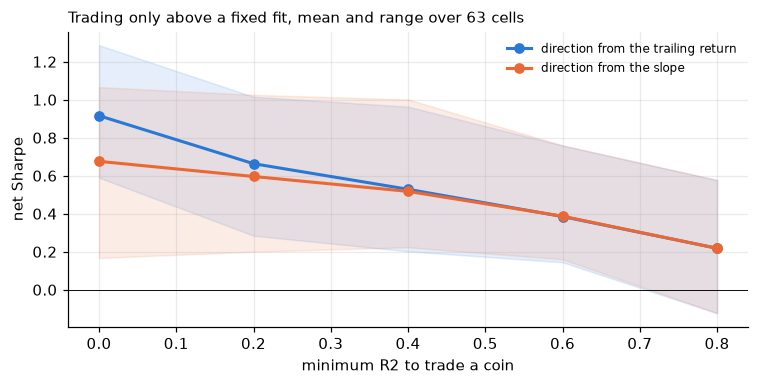

In [7]:
CUTS = [0.0, 0.2, 0.4, 0.6, 0.8]
rows = []
for name, b in books.items():
    for D in BLOCK:
        ret = trail[D].resample(WEEKS[name]).last().reindex(b.W.index)
        corr = fit[D].resample(WEEKS[name]).last().reindex(b.W.index)
        r2 = (corr ** 2).shift(1)
        for label, sig in [('trailing return', np.sign(ret)), ('slope', np.sign(corr))]:
            full = b.sized(sig.shift(1))
            for cut in CUTS:
                kept = full.where(r2 >= cut, 0.0)
                net = b.run(kept).net
                early = halves(net.index)
                row = {'day': name, 'days': D, 'direction': label, 'cut': cut, 'all': sharpe(net), 'earlier': sharpe(net[early]), 'later': sharpe(net[~early]),
                       'return % a year': net.mean() * 52 * 100, 'share of book held': kept.abs().sum(axis=1).reindex(net.index).mean()}
                row['return % per unit held'] = row['return % a year'] / row['share of book held']
                if label == 'trailing return' and cut > 0:
                    row['removed coins'] = sharpe(b.run(full.where(r2 < cut, 0.0)).net)
                rows.append(row)
sweep = pd.DataFrame(rows)

for label in ('trailing return', 'slope'):
    print(f'direction from the {label}, mean over 9 lookbacks and 7 rebalance days')
    print(sweep[sweep.direction == label].groupby('cut')[['all', 'earlier', 'later', 'return % a year', 'share of book held', 'return % per unit held', 'removed coins']].mean().dropna(axis=1, how='all').round(2))
    print()

base = sweep[(sweep.direction == 'trailing return') & (sweep.cut == 0)].set_index(['day', 'days'])
print('share of the 63 cells where the cut beats no cut, direction from the trailing return')
print(pd.DataFrame({cut: {k: (sweep[(sweep.direction == 'trailing return') & (sweep.cut == cut)].set_index(['day', 'days'])[k] > base[k]).mean()
                          for k in ('all', 'earlier', 'later')} for cut in CUTS[1:]}).round(2))

fig, ax = plt.subplots(figsize=(7, 3.6))
for label, color in [('trailing return', BLUE), ('slope', ORANGE)]:
    g = sweep[sweep.direction == label].groupby('cut')['all']
    ax.fill_between(CUTS, g.min(), g.max(), color=color, alpha=0.12)
    ax.plot(CUTS, g.mean(), marker='o', color=color, label=f'direction from the {label}')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('minimum R2 to trade a coin'); ax.set_ylabel('net Sharpe')
ax.set_title('Trading only above a fixed fit, mean and range over 63 cells', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

A fixed cut makes the book worse at every level, and steadily. With no cut the book makes 0.92. Requiring an $R^2$ of 0.2 keeps 70% of the book and makes 0.66. At 0.4 it keeps half and makes 0.53, at 0.6 a third and 0.39, at 0.8 an eighth and 0.22. The cut beats no cut in 3% of the 63 cells or fewer, and in none from 0.6 up.

The removed coins say why. The coins a cut of 0.2 throws out, the worst fitting 30% of the book, make 0.95 as a book of their own. The trades the rule calls not a trend earn as much as the ones it keeps. The cut does not remove bad trades, it removes diversification, and what is left is a smaller and more concentrated book.

Return falls faster than exposure. At a cut of 0.6 the book holds 35% of its weight and earns 13% a year against 51%. On each unit still held that is 38% against 51%, so the kept trades earn less per dollar, and the lower Sharpe is not only the flat weeks.

The later weeks are flat across cuts, 0.42 down to 0.26, all under the 0.62 with no cut.

Taking direction from the slope starts lower, 0.68, and converges on the same numbers as the cut rises, since a well fitted line and the trailing return agree on direction.

So sitting out when no trend is discernible does not help. A poorly fitting line does not mark a sideways coin whose signal is noise. Over four weeks the direction of the move carries the information whether or not the path to it was straight.

## Steepness, and steepness with fit

$R^2$ says how tightly prices hug the line. It says nothing about how steep the line is. A coin can crawl up in a perfectly straight line, tight but shallow, or lurch a long way in a ragged one, steep but loose. A trend worth the name might need both.

Steepness is the fitted move over the window measured in the coin's own volatility.

$$z = \frac{\lvert b \rvert \, D}{\sigma \sqrt{D / 7}}$$

- $b$ is the slope of the fitted line, in log price a day.
- $D$ is the window in days, so $b\,D$ is the move the line describes.
- $\sigma$ is the coin's weekly volatility over the prior 12 weeks, and $\sigma\sqrt{D/7}$ scales it to the window.
- $z$ is the move in units of what the coin normally does over that long. Near 0 is flat, 2 is a move twice its usual size.

Three tests on the same block. The plain sign inside thirds by steepness, shallow, middle and steep. A fixed cut on steepness, where a coin whose line is too shallow is not traded at all, with direction from the trailing return and from the slope itself. And the two together, steepness thirds crossed with tightness thirds, nine boxes, to see whether the steep and tight corner is where trend lives.

A cut that sits out lowers the Sharpe by itself, since flat time earns nothing. So each cut is read three ways. The book as traded, flat time counted. The kept coins as a fully invested book, which is the quality of the trades the cut keeps. And the removed coins as a book, which is the quality of the trades it drops.

steepness and tightness, rank correlation across coin-weeks 0.90

plain sign by steepness third, net Sharpe, mean over 9 lookbacks and 7 rebalance days
            all  earlier  later
steepness                      
low        0.75     0.92   0.44
mid        0.79     1.01   0.43
high       0.75     0.87   0.57

fixed cut on steepness, direction from the trailing return
     with flat time  earlier  later  share of book held  weeks fully flat  return % per unit held  kept coins, fully invested  removed coins
cut                                                                                                                                         
0.0            0.92     1.09   0.62                1.00              0.00                   51.18                        0.92            NaN
0.5            0.63     0.75   0.44                0.64              0.00                   45.94                        0.79           0.95
1.0            0.49     0.58   0.36                0.37         

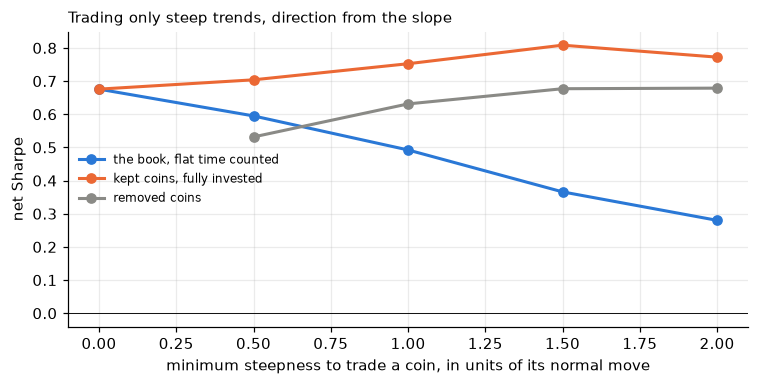

In [8]:
slope = {D: level.rolling(D).cov(clock).div(clock.rolling(D).var(), axis=0).where(fit[D].notna()) for D in BLOCK}
Z_CUTS = [0.0, 0.5, 1.0, 1.5, 2.0]
names3 = ['low', 'mid', 'high']

def thirds_of(x):
    """0, 1 or 2 by each week's cross-sectional thirds."""
    lo, hi = x.quantile(1 / 3, axis=1), x.quantile(2 / 3, axis=1)
    return (x.gt(lo, axis=0).astype(float) + x.ge(hi, axis=0).astype(float)).where(x.notna())

rows, grid_rows, z_rows, pair = [], [], [], []
for name, b in books.items():
    for D in BLOCK:
        ret = trail[D].resample(WEEKS[name]).last().reindex(b.W.index)
        ok = (b.LIQ.shift(-1) >= 1e7) & b.VOL.shift(-1).notna() & ret.notna()
        r2 = (fit[D].resample(WEEKS[name]).last().reindex(b.W.index) ** 2).where(ok)
        line = slope[D].resample(WEEKS[name]).last().reindex(b.W.index)
        z = (line.abs() * D / (b.VOL.shift(-1) * np.sqrt(D / 7))).where(ok & r2.notna())
        r2 = r2.where(z.notna())
        sign = np.sign(ret)
        steep3, clean3 = thirds_of(z), thirds_of(r2)
        pair.append(pd.concat([z.stack(), r2.stack()], axis=1).corr(method='spearman').iloc[0, 1])
        for k in range(3):
            rows.append({'steepness': names3[k], **three(b, sign.where(steep3 == k))})
            for j in range(3):
                box = (steep3 == k) & (clean3 == j)
                grid_rows.append({'steepness': names3[k], 'tightness': names3[j], 'sharpe': three(b, sign.where(box))['all'], 'share': box.sum().sum() / z.notna().sum().sum()})
        for label, sig in [('trailing return', sign), ('slope', np.sign(line))]:
            full = b.sized(sig.shift(1))
            for cut in Z_CUTS:
                passes = z >= cut
                kept = full.where(passes.shift(1, fill_value=False), 0.0)
                net = b.run(kept).net
                early = halves(net.index)
                held_share = kept.abs().sum(axis=1).reindex(net.index)
                z_rows.append({'direction': label, 'cut': cut, 'with flat time': sharpe(net), 'earlier': sharpe(net[early]), 'later': sharpe(net[~early]),
                               'share of book held': held_share.mean(), 'weeks fully flat': (held_share == 0).mean(),
                               'return % per unit held': net.mean() * 5200 / held_share.mean(),
                               'kept coins, fully invested': sharpe(b.run(b.sized(sig.where(passes).shift(1))).net),
                               'removed coins': sharpe(b.run(full.where(~passes.shift(1, fill_value=False), 0.0)).net) if cut > 0 else np.nan})
steep, boxes, z_sweep = pd.DataFrame(rows), pd.DataFrame(grid_rows), pd.DataFrame(z_rows)

print(f'steepness and tightness, rank correlation across coin-weeks {np.mean(pair):.2f}\n')
print('plain sign by steepness third, net Sharpe, mean over 9 lookbacks and 7 rebalance days')
print(steep.groupby('steepness')[['all', 'earlier', 'later']].mean().reindex(names3).round(2))
for label in ('trailing return', 'slope'):
    print(f'\nfixed cut on steepness, direction from the {label}')
    print(z_sweep[z_sweep.direction == label].drop(columns='direction').groupby('cut').mean().round(2).to_string())
box_mean = boxes.groupby(['steepness', 'tightness'])[['sharpe', 'share']].mean()
print('\nplain sign in each box, net Sharpe over all weeks, rows steepness and columns tightness')
print(box_mean['sharpe'].unstack().reindex(index=names3, columns=names3).round(2))
print('\nshare of coin-weeks in each box')
print(box_mean['share'].unstack().reindex(index=names3, columns=names3).round(2))

fig, ax = plt.subplots(figsize=(7, 3.6))
for col, color, lab in [('with flat time', BLUE, 'the book, flat time counted'), ('kept coins, fully invested', ORANGE, 'kept coins, fully invested'), ('removed coins', GREY, 'removed coins')]:
    g = z_sweep[z_sweep.direction == 'slope'].groupby('cut')[col].mean()
    ax.plot(g.index, g.values, marker='o', color=color, label=lab)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('minimum steepness to trade a coin, in units of its normal move'); ax.set_ylabel('net Sharpe')
ax.set_title('Trading only steep trends, direction from the slope', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

Steepness and tightness turn out to be nearly the same measurement. Across coin-weeks they rank coins alike, a rank correlation of 0.90. Measured against a coin's own volatility, a big move is a straight one, since the noise around the line is what the volatility counts. Only 1% of coin-weeks are shallow and tight, and almost none are steep and loose. The two ideas do not separate enough to give a fourth corner worth trading.

Steepness alone does not help. The plain sign makes 0.75 in the shallow third, 0.79 in the middle and 0.75 in the steep third. A big move is no more likely to continue than a small one. In the later weeks the steep third leads, 0.57 against 0.44, and in the earlier weeks it trails, so there is no stable tilt.

The fixed cut is read three ways. As traded, with flat time counted, the Sharpe falls from 0.92 with no cut to 0.63 at half a normal move, 0.49 at one and 0.28 at two, where the book holds 9% of its weight and is fully flat 11% of weeks. The kept coins as a fully invested book, which takes flat time out of it, make 0.77 to 0.81 at every cut against 0.92 for every coin. And the removed coins make 0.94 to 0.98. So the loss is not only time out of the market. The steep trends the cut keeps are a worse book than the shallow ones it drops, and return per unit held falls from 51% a year to 39%.

Letting the slope decide both direction and whether to trade is the one place a cut helps, and only against itself. The slope's sign on every coin makes 0.68. Kept to steep lines and fully invested it makes 0.70, 0.75, 0.81 and 0.77 as the cut rises, and the coins it removes make 0.53 to 0.68. A shallow line is where the slope misreads direction, so dropping shallow lines repairs the slope. It repairs it up to 0.81 at best, still under the 0.92 the trailing return makes on every coin with no cut at all. As traded, with flat time counted, it never passes 0.60.

In the nine boxes the diagonal carries nearly all the coins, 0.78 shallow and loose, 0.80 middle, 0.71 steep and tight. The steep and tight corner, the cleanest trends by both measures, is the lowest of the three.

## The steep slope rule against the plain sign

The rule in full. Fit a line through the last 28 days. Trade a coin only if the line is steep enough, in the direction the line points, and stay out of it otherwise. Set it against the plain sign as two books a trader could actually hold, and ask whether the rule makes more and loses less while it is in.

Both are built as seven-slice books so no rebalance day is chosen, and both are priced off the measured cost ladder at a \$100k book instead of the provisional cost, since a rule that holds fewer coins trades each one in larger size. The rule is read while trading, its capital always spread over the coins that pass, which is the fair comparison with a book that holds every coin.

Each book gets its Sharpe, its return, its worst week, its share of losing weeks and its deepest drawdown in summed weekly returns. Then how it does in the weeks the plain sign loses and the weeks it wins. Then each year. Last, the probability it is real against the luck bar, at the two trial counts the lane has used and with this section's own books added.

327 weeks from 2020-06-07, cost off the ladder at a $100k book

                        Sharpe  return % a year  worst week %  weeks losing %  deepest drawdown  when plain loses, % a week  when plain wins, % a week  correlation with plain
plain sign, every coin    1.04            55.50        -24.63           45.57             -0.39                       -4.50                       5.73                    1.00
slope, steepness 0.0      0.67            36.52        -24.58           46.48             -0.71                       -4.27                       4.87                    0.91
slope, steepness 0.5      0.73            46.23        -36.23           44.04             -0.84                       -4.82                       5.67                    0.87
slope, steepness 1.0      0.75            51.13        -46.78           45.26             -1.05                       -4.71                       5.75                    0.79
slope, steepness 1.5      0.89            65.57        -48.05

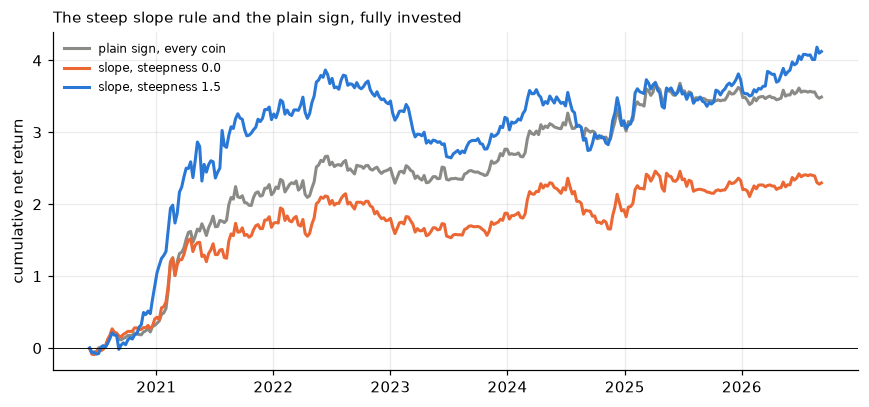

In [9]:
import costs
ladder = costs.ladder(costs.sample(['2023-03-10', '2024-03-10', '2025-03-10', '2026-06-10']))
D = 28

def slice_daily_at(b, w, **kw):
    """One slice's net return by day, priced by the keyword costs."""
    r = b.run(w, **kw)
    by_day = b.hold(w).reindex(held.index, method='bfill').fillna(0.0)
    since_rebalance = held.groupby(b.W.index.searchsorted(held.index)).cumsum()
    gross = (by_day * (np.exp(since_rebalance) - np.exp(since_rebalance - held))).sum(axis=1)
    return gross.add((r.funding + r.cost).reindex(held.index).fillna(0.0), fill_value=0.0)

def seven(weights):
    """Weekly net of the seven-slice book whose slice weights come from weights(name, b)."""
    parts = [slice_daily_at(b, weights(name, b), fit=ladder, size=1e5) for name, b in books.items()]
    weekly = pd.concat(parts, axis=1).mean(axis=1).resample('W-SUN').sum()
    return weekly.loc[(weekly != 0).idxmax():]

def pieces(name, b):
    ret = trail[D].resample(WEEKS[name]).last().reindex(b.W.index)
    ok = (b.LIQ.shift(-1) >= 1e7) & b.VOL.shift(-1).notna() & ret.notna()
    line = slope[D].resample(WEEKS[name]).last().reindex(b.W.index)
    z = (line.abs() * D / (b.VOL.shift(-1) * np.sqrt(D / 7))).where(ok)
    return np.sign(ret), np.sign(line), z

def plain(name, b):
    return b.sized(pieces(name, b)[0].shift(1))

def rule(cut, invested=True):
    def weights(name, b):
        _, direction, z = pieces(name, b)
        if invested:
            return b.sized(direction.where(z >= cut).shift(1))
        return b.sized(direction.shift(1)).where((z >= cut).shift(1, fill_value=False), 0.0)
    return weights

series = {'plain sign, every coin': seven(plain)}
for cut in (0.0, 0.5, 1.0, 1.5, 2.0):
    series[f'slope, steepness {cut:.1f}'] = seven(rule(cut))
as_traded = {cut: seven(rule(cut, invested=False)) for cut in (0.5, 1.0, 1.5, 2.0)}
start = max(s.index[0] for s in series.values())
series = {k: v.loc[start:] for k, v in series.items()}
base = series['plain sign, every coin']
down, up = base < 0, base > 0

def drawdown(x):
    c = x.cumsum()
    return (c - c.cummax()).min()

neff_here = gate.effective_trials(pd.DataFrame(series))
stats = pd.DataFrame({k: {'Sharpe': sharpe(v), 'return % a year': v.mean() * 5200, 'worst week %': v.min() * 100,
                          'weeks losing %': (v < 0).mean() * 100, 'deepest drawdown': drawdown(v),
                          'when plain loses, % a week': v[down].mean() * 100, 'when plain wins, % a week': v[up].mean() * 100,
                          'correlation with plain': v.corr(base)} for k, v in series.items()}).T
print(f'{len(base)} weeks from {start.date()}, cost off the ladder at a $100k book\n')
print(stats.round(2).to_string())

print('\nSharpe by year')
print(pd.DataFrame({k: v.groupby(v.index.year).apply(sharpe) for k, v in series.items()}).T.round(2).to_string())

print('\nthe rule minus the plain sign, week by week')
edge = pd.DataFrame({k: {'mean % a week': (v - base).mean() * 100, 't': (v - base).mean() / (v - base).std() * np.sqrt(len(base))}
                     for k, v in series.items() if k != 'plain sign, every coin'}).T
print(edge.round(2).to_string())

print(f"\nprobability real. This section's {len(series)} books are worth {neff_here:.1f} independent tests")
prob = pd.DataFrame({k: {f'{t:.0f} trials': gate.significance(v, t)[0] for t in (42, 74, 74 + neff_here)} for k, v in series.items()}).T
print(prob.round(2).to_string())
print('luck bar', {f'{t:.0f} trials': round(gate.significance(base, t)[1], 2) for t in (42, 74, 74 + neff_here)})

print('\nas traded, idle capital earning nothing')
print(pd.DataFrame({f'slope, steepness {cut:.1f}': {'Sharpe': sharpe(v.loc[start:]), 'return % a year': v.loc[start:].mean() * 5200,
                                                     'deepest drawdown': drawdown(v.loc[start:])} for cut, v in as_traded.items()}).T.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
for k, color in [('plain sign, every coin', GREY), ('slope, steepness 0.0', ORANGE), ('slope, steepness 1.5', BLUE)]:
    ax.plot(series[k].cumsum(), color=color, label=k)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('cumulative net return'); ax.set_title('The steep slope rule and the plain sign, fully invested', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

The plain sign does lose money, often. It loses in 46% of weeks, its worst week is $-24.6\%$, its deepest drawdown is 0.39 in summed weekly returns, and it loses 2026. It makes 1.04 over the 327 weeks, 55% a year, at the measured cost.

The steep slope rule does not lose less. It loses in 44 to 46% of weeks at every cut, the same as the plain sign. In the weeks the plain sign loses, 4.5% on average, the rule loses 4.1 to 4.8%, and only the strictest cut loses clearly less, 3.1%. Its worst week is twice as bad, $-36\%$ to $-48\%$ against $-25\%$, and its deepest drawdown three to four times as deep, 0.84 to 1.73 against 0.39. Holding only the coins with steep lines is holding few coins, and a few coins move together.

It does make more, at the strict cuts. Return rises from 37% a year with no cut to 66% at 1.5 and 79% at 2.0, against 55% for the plain sign. The Sharpe rises with it, 0.67 to 0.89, and stays under the plain sign's 1.04, because the extra return comes with more than its share of extra risk.

Week by week the rule is not distinguishable from the plain sign. The slope on every coin is worse, by 0.37% a week at t $-2.08$. At a cut of 1.5 the rule is ahead by 0.19% a week at t 0.46, and at 2.0 by 0.46% at t 0.76. Neither is evidence of an edge over the plain sign.

The years are where it differs. The plain sign is positive every year to 2025 and loses 2026, $-0.48$. The rule at 1.5 and 2.0 is positive in 2026, 1.07 and 1.23, but loses or goes flat in the middle years, $-0.40$ in 2023 at 1.5, $-0.44$ in 2022 at 2.0. It is not the same book with a filter on. At a cut of 2.0 its returns correlate 0.50 with the plain sign's. It is a different, more concentrated bet that happened to pay in 2026, on the 35 weeks of that year and the handful of coins that passed.

Against the lane's search the plain sign is real with probability 0.58 to 0.67. The rule is 0.23 to 0.38 up to a cut of 1.0, and 0.42 to 0.52 at 1.5 and 2.0. The strict cuts sit at the park line and under the plain sign. The cut was also chosen after seeing it work, which these counts do not charge for.

As traded, with the capital outside the passing coins idle, the rule makes 0.61 at a cut of 0.5 down to 0.32 at 2.0, and 29% a year down to 4%.

## All three together

A trend by the full definition has three parts. The direction of the line, how steep it is, and how tightly the prices hug it. The last section used the first two. This one adds the third. The slope sets the direction, and a coin is traded only if its line clears a steepness cut and an $R^2$ cut at once.

Sweep both cuts as a grid, steepness over 0, 1.0, 1.5 and 2.0 and $R^2$ over 0, 0.4, 0.6 and 0.8, each as a seven-slice book at 28 days, fully invested in the coins that pass, at the measured cost. Steepness and tightness rank coins alike, so most of the grid should repeat itself. The question is whether the corner that demands both does better than either cut alone.

In [10]:
def rule3(z_cut, r2_cut):
    def weights(name, b):
        _, direction, z = pieces(name, b)
        r2 = fit[D].resample(WEEKS[name]).last().reindex(b.W.index) ** 2
        return b.sized(direction.where((z >= z_cut) & (r2 >= r2_cut)).shift(1))
    return weights

def passing(z_cut, r2_cut):
    """Share of eligible coin-weeks that clear both cuts, on the Sunday book."""
    _, _, z = pieces('Sun', sun)
    r2 = fit[D].resample('W-SUN').last().reindex(sun.W.index) ** 2
    return ((z >= z_cut) & (r2 >= r2_cut)).sum().sum() / z.notna().sum().sum()

Z3, R3 = [0.0, 1.0, 1.5, 2.0], [0.0, 0.4, 0.6, 0.8]
grid3 = {(zc, rc): seven(rule3(zc, rc)).loc[start:] for zc in Z3 for rc in R3}

def table(f):
    t = pd.DataFrame({rc: {zc: f(grid3[(zc, rc)]) for zc in Z3} for rc in R3})
    t.index.name, t.columns.name = 'steepness cut', 'R2 cut'
    return t

print(f"plain sign, every coin   Sharpe {sharpe(base):.2f}   return {base.mean() * 5200:.0f}% a year   drawdown {drawdown(base):.2f}   2026 {sharpe(base[base.index.year == 2026]):.2f}   probability real {gate.significance(base, 74)[0]:.2f}\n")
for title, f in [('Sharpe', sharpe), ('return % a year', lambda v: v.mean() * 5200), ('deepest drawdown', drawdown), ('worst week %', lambda v: v.min() * 100),
                 ('Sharpe in 2026', lambda v: sharpe(v[v.index.year == 2026])), ('years positive of 7', lambda v: (v.groupby(v.index.year).apply(sharpe) > 0).sum()),
                 ('probability real, 74 trials', lambda v: gate.significance(v, 74)[0]), ('t of the edge over the plain sign', lambda v: (v - base).mean() / (v - base).std() * np.sqrt(len(base))),
                 ('correlation with the plain sign', lambda v: v.corr(base))]:
    print(title); print(table(f).round(2).to_string()); print()
print('share of coin-weeks passing both cuts')
print(pd.DataFrame({rc: {zc: passing(zc, rc) for zc in Z3} for rc in R3}).rename_axis('steepness cut').rename_axis('R2 cut', axis=1).round(2).to_string())
print(f'\nthe 16 books are worth {gate.effective_trials(pd.DataFrame(grid3)):.1f} independent tests')

corner = grid3[(2.0, 0.8)]
both = (base / base.std() + corner / corner.std()) / 2 * base.std()
print('\nthe plain sign and the strictest corner held together at equal risk, scaled to the plain sign')
print(pd.DataFrame({k: {'Sharpe': sharpe(v), 'return % a year': v.mean() * 5200, 'deepest drawdown': drawdown(v), 'worst week %': v.min() * 100,
                        'Sharpe in 2026': sharpe(v[v.index.year == 2026]), 'years positive of 7': (v.groupby(v.index.year).apply(sharpe) > 0).sum(),
                        'probability real, 74 trials': gate.significance(v, 74)[0]}
                    for k, v in [('plain sign', base), ('strictest corner', corner), ('both', both)]}).T.round(2).to_string())
print('\nSharpe by year')
print(pd.DataFrame({k: v.groupby(v.index.year).apply(sharpe) for k, v in [('plain sign', base), ('strictest corner', corner), ('both', both)]}).T.round(2).to_string())
held_count = pd.concat([rule3(2.0, 0.8)(n, b).fillna(0.0).ne(0).sum(axis=1).reindex(sun.W.index, method='nearest').loc[start:] for n, b in books.items()], axis=1).mean(axis=1)
print(f'\ncoins held by the strictest corner, per slice   median {held_count.median():.0f}   weeks under 3 coins {(held_count < 3).mean():.0%}   weeks with none {(held_count == 0).mean():.0%}')

plain sign, every coin   Sharpe 1.04   return 56% a year   drawdown -0.39   2026 -0.48   probability real 0.59

Sharpe
R2 cut          0.0   0.4   0.6   0.8
steepness cut                        
0.0            0.67  0.72  0.81  0.61
1.0            0.75  0.76  0.81  0.65
1.5            0.89  0.90  0.92  0.83
2.0            0.89  0.88  0.92  0.97

return % a year
R2 cut           0.0    0.4    0.6     0.8
steepness cut                             
0.0            36.52  47.70  56.23   46.87
1.0            51.13  52.21  56.83   50.40
1.5            65.57  66.63  69.67   71.99
2.0            79.31  78.88  83.57  109.90

deepest drawdown
R2 cut          0.0   0.4   0.6   0.8
steepness cut                        
0.0           -0.71 -0.92 -0.98 -1.22
1.0           -1.05 -1.02 -1.06 -1.12
1.5           -1.22 -1.24 -1.10 -1.07
2.0           -1.73 -1.76 -1.79 -0.91

worst week %
R2 cut           0.0    0.4    0.6    0.8
steepness cut                            
0.0           -24.58 -44.88 -45.31

R2 cut          0.0   0.4   0.6   0.8
steepness cut                        
0.0            1.00  0.55  0.36  0.13
1.0            0.37  0.36  0.29  0.13
1.5            0.18  0.18  0.17  0.09
2.0            0.08  0.08  0.08  0.06

the 16 books are worth 2.3 independent tests

the plain sign and the strictest corner held together at equal risk, scaled to the plain sign
                  Sharpe  return % a year  deepest drawdown  worst week %  Sharpe in 2026  years positive of 7  probability real, 74 trials
plain sign          1.04            55.50             -0.39        -24.63           -0.48                  6.0                         0.59
strictest corner    0.97           109.90             -0.91        -38.39            1.18                  7.0                         0.52
both                1.22            53.67             -0.35        -17.96            0.93                  7.0                         0.76

Sharpe by year
day               2020  2021  2022  2023  2024  2025  2


coins held by the strictest corner, per slice   median 2   weeks under 3 coins 56%   weeks with none 6%


No cell of the grid beats the plain sign on its own. The sixteen books make 0.61 to 0.97 against 1.04, and are real with probability 0.19 to 0.52 against 0.59.

The $R^2$ cut adds little to the steepness cut until it is strict. At a steepness of 1.5, cuts of 0.4 and 0.6 remove almost nothing, 18% of coin-weeks pass with or without them, because a steep line is already a tight one. Only the 0.8 column changes the book. The sixteen books are worth 2.3 independent tests.

The strictest corner is the best of them. Steepness of 2.0 and $R^2$ of 0.8 makes 0.97, close to the plain sign, with twice the return, 110% a year against 56%. It is the only book positive in all seven years, 2026 included at 1.18. Its neighbours agree, 0.92 with the $R^2$ cut at 0.6 and 0.83 with steepness at 1.5. Week by week it is ahead of the plain sign at t 1.29, the highest in the grid and still short of evidence, and it is the best of sixteen looked at.

It is a very small book. Only 6% of coin-weeks pass both cuts, and they cluster in time. The median slice holds 2 coins, 56% of weeks hold under 3, and 6% hold none. That is where the risk comes from, a deepest drawdown of 0.91 against 0.39 and a worst week of $-38\%$ against $-25\%$. Fully invested in two coins is not a book anyone would run at size.

What it is good for is company. Its returns correlate 0.37 with the plain sign's, the lowest in the grid. Held together at equal risk the two make 1.22, above either alone, with a shallower drawdown than the plain sign, 0.35 against 0.39, a milder worst week, $-18\%$ against $-25\%$, and every year positive, 0.93 in 2026. Against 74 trials that pair is real with probability 0.76. The count does not charge for picking the corner out of sixteen or for pairing it after seeing both, so 0.76 is a ceiling.

## The same fit on hourly prices

A line through 28 daily closes is a coarse picture of a path. The archive carries hourly bars for every coin, so the same line can be fitted through about 670 hourly prices instead. If the daily fit was too blunt to tell a real trend from a wander, the hourly fit should separate them better.

Stream hourly closes for every crypto perp from 2020, fit the line over the trailing $D$ days of hours ending at each day's close, and rerun both tests. The thirds, and the fixed cut. Direction comes from the trailing return, which is the same number however finely the path is sampled.

In [11]:
symbols = [s for s in stream.listed('2020-01-01', '2026-09-01') if s not in drop]
hourly = stream.hourly_closes(symbols, '2020-01-01', '2026-09-01', log=lambda *a, **k: None)

def hourly_fit(prices, windows):
    """Correlation of hourly log price with time over the trailing days, read at each day's last hour."""
    hours = pd.date_range(prices.index[0].floor('D'), prices.index[-1].ceil('D') - pd.Timedelta(hours=1), freq='h')
    y = np.log(prices.reindex(hours).astype('float64')).values
    seen = ~np.isnan(y)
    y = np.where(seen, y - np.nanmean(y, axis=0), 0.0)
    t = np.arange(len(hours))[:, None] / 24.0
    t = t - t.mean()
    run = lambda a: np.vstack([np.zeros((1, a.shape[1])), np.cumsum(a, axis=0)])
    sums = [run(a) for a in (seen * 1.0, y, y * y, seen * t, seen * t * t, y * t)]
    ends = np.arange(24, len(hours) + 1, 24)
    out = {}
    for D in windows:
        start = np.maximum(ends - 24 * D, 0)
        n, sy, syy, st, stt, sty = (a[ends] - a[start] for a in sums)
        with np.errstate(all='ignore'):
            corr = (n * sty - st * sy) / np.sqrt((n * stt - st * st) * (n * syy - sy * sy))
        corr[(n < 24 * D * 5 / 7) | (ends < 24 * D)[:, None]] = np.nan
        out[D] = pd.DataFrame(corr, index=hours[ends - 1].floor('D'), columns=prices.columns)
    return out

parts = [hourly_fit(hourly.iloc[:, i:i + 50].dropna(how='all'), BLOCK) for i in range(0, hourly.shape[1], 50)]
fit_h = {D: pd.concat([p[D] for p in parts], axis=1).reindex(index=daily.index, columns=daily.columns) for D in BLOCK}

day_end = hourly.resample('D').last().reindex(index=close.index, columns=close.columns)
both = pd.concat([(fit_h[28] ** 2).stack(), (fit[28] ** 2).stack()], axis=1, keys=['hourly', 'daily']).dropna()
print(f'hourly bars {hourly.shape}   {hourly.index.min()} .. {hourly.index.max()}')
gap = ((day_end - close) / close).abs().where(volume > 0)
print(f'last hourly close of the day against the daily close, off by over 0.01% on {int((gap > 1e-4).sum().sum())} of {int(gap.notna().sum().sum()):,} coin-days')
print(f"R2 at 28 days, {len(both):,} coin-days   median hourly {both.hourly.median():.2f}   median daily {both.daily.median():.2f}   rank correlation {both.corr(method='spearman').iloc[0, 1]:.3f}\n")

rows, cut_rows = [], []
for name, b in books.items():
    for D in BLOCK:
        ret = trail[D].resample(WEEKS[name]).last().reindex(b.W.index)
        r2 = (fit_h[D].resample(WEEKS[name]).last().reindex(b.W.index) ** 2).where((b.LIQ.shift(-1) >= 1e7) & b.VOL.shift(-1).notna() & ret.notna())
        held_ = r2.notna()
        choppy = r2.le(r2.quantile(1 / 3, axis=1), axis=0) & held_
        clean = r2.ge(r2.quantile(2 / 3, axis=1), axis=0) & held_
        sign = np.sign(ret)
        for label, sig in [('plain sign', sign), ('sign, choppy third', sign.where(choppy)), ('sign, middle third', sign.where(held_ & ~choppy & ~clean)), ('sign, clean third', sign.where(clean))]:
            rows.append({'day': name, 'days': D, 'book': label, **three(b, sig)})
        full, r2w = b.sized(sign.shift(1)), r2.shift(1)
        for cut in CUTS:
            kept = full.where(r2w >= cut, 0.0)
            net = b.run(kept).net
            early = halves(net.index)
            share = kept.abs().sum(axis=1).reindex(net.index).mean()
            cut_rows.append({'day': name, 'days': D, 'cut': cut, 'all': sharpe(net), 'earlier': sharpe(net[early]), 'later': sharpe(net[~early]),
                             'share of book held': share, 'return % per unit held': net.mean() * 5200 / share,
                             'removed coins': sharpe(b.run(full.where(r2w < cut, 0.0)).net) if cut > 0 else np.nan})
res_h, sweep_h = pd.DataFrame(rows), pd.DataFrame(cut_rows)

print('thirds by the hourly fit, net Sharpe, mean over 9 lookbacks and 7 rebalance days')
print(res_h.groupby('book')[['all', 'earlier', 'later']].mean().loc[order[:4]].round(2))
cell_h = res_h.pivot_table(index=['day', 'days'], columns='book', values='all')
print(f"clean third beats choppy third in {(cell_h['sign, clean third'] > cell_h['sign, choppy third']).mean():.0%} of cells, beats the plain sign in {(cell_h['sign, clean third'] > cell_h['plain sign']).mean():.0%}\n")
print('fixed cut on the hourly fit')
print(sweep_h.groupby('cut')[['all', 'earlier', 'later', 'share of book held', 'return % per unit held', 'removed coins']].mean().round(2))

hourly bars (58440, 681)   2020-01-01 00:00:00+00:00 .. 2026-08-31 23:00:00+00:00
last hourly close of the day against the daily close, off by over 0.01% on 2 of 568,938 coin-days


R2 at 28 days, 537,066 coin-days   median hourly 0.45   median daily 0.45   rank correlation 0.987



thirds by the hourly fit, net Sharpe, mean over 9 lookbacks and 7 rebalance days
                     all  earlier  later
book                                    
plain sign          0.92     1.09   0.62
sign, choppy third  0.77     0.96   0.42
sign, middle third  0.86     1.02   0.60
sign, clean third   0.67     0.81   0.44
clean third beats choppy third in 48% of cells, beats the plain sign in 6%

fixed cut on the hourly fit
      all  earlier  later  share of book held  return % per unit held  \
cut                                                                     
0.0  0.92     1.09   0.62                1.00                   51.19   
0.2  0.67     0.82   0.43                0.70                   46.77   
0.4  0.53     0.65   0.34                0.53                   42.93   
0.6  0.39     0.47   0.26                0.34                   38.12   
0.8  0.25     0.25   0.27                0.12                   34.66   

     removed coins  
cut                 
0.0            

Hourly prices change nothing. The hourly and daily fits rank coins almost identically, a rank correlation of 0.987, and the typical $R^2$ is 0.45 either way. A line through 670 points measures the same thing as a line through 28. The straightness of a four-week path is a property of the path, not of how finely it is sampled.

The tests come back the same. By the hourly fit the clean third makes 0.67, the choppy third 0.77 and every coin together 0.92. Clean beats choppy in 48% of cells and beats the plain sign in 6%.

The fixed cut falls the same way, 0.92 with no cut, 0.67 at 0.2, 0.39 at 0.6 and 0.25 at 0.8. The coins each cut removes make 0.92 to 1.08 on their own.

Sitting out lowers a Sharpe by itself, since flat weeks earn nothing, so the fair comparison is the return on each unit of the book still held. That falls too, from 51% a year with no cut to 47% at 0.2, 38% at 0.6 and 35% at 0.8. The trades the cut keeps are worse per dollar than the ones it drops.

The hourly bars agree with the daily bars. The last hourly close of each day matches the daily close on all but 2 of 568,938 coin-days.

## Verdict

The 4-week book is not a lucky cell. From 25 to 33 days the per coin book earns on every rebalance day, 0.59 to 1.29, and the Sunday book the lane has quoted is the weakest of the seven at 28 days. The effect is a block about a week wide centred near 29 days.

Rebalancing one seventh of the book each day removes the choice of day. That book makes 1.02 at 28 days, positive every year to 2025 and negative in 2026, real with probability 0.58 to 0.67 against the lane's search.

The 3-week hole is mostly the Sunday. By the day the surface dips to about 0.35 between 16 and 22 days and rises smoothly from there. The band from 3 to 6 weeks straddles the dip and the block.

Lookbacks under two weeks are not robust. Their sign depends on the rebalance day.

A cleaner trend does not continue better. Sorting coins by how well a straight line fits their last 25 to 33 days, the clean third makes 0.68, the choppy third 0.76 and every coin together 0.92. Trading only above a fixed fit lowers the Sharpe at every cut, 0.92 with none to 0.39 at 0.6, the coins the cut removes earn as much as the ones it keeps, and the kept trades earn less per dollar held. The slope of the line reads direction worse than the two endpoints, 0.68 against 0.92. Steepness is no better. A coin's move in units of its own volatility ranks coins almost as tightness does, a rank correlation of 0.90, the steep third makes 0.75 against 0.75 for the shallow third, and trading only steep lines makes 0.77 to 0.81 fully invested against 0.92 for every coin. Set against the plain sign as a book, the steep slope rule earns more at strict cuts, 66% a year at 1.5 against 55%, with twice the worst week and three times the drawdown, a Sharpe of 0.89 against 1.04, no weekly edge at t 0.46, and a probability of being real of 0.42 to 0.51 against 0.58 to 0.67. It is positive in 2026 where the plain sign is not, on few coins and 35 weeks. With all three parts, direction from the slope and cuts on both steepness and fit, no book beats the plain sign alone, 0.61 to 0.97 against 1.04. The strictest corner, steepness 2.0 and $R^2$ 0.8, makes 0.97 with every year positive, on a median of 2 coins. It moves differently from the plain sign, a correlation of 0.37, and the two held together make 1.22 with every year positive, an exploratory lead for the strategy phase and not a finding. Fitting the line on hourly prices gives the same ranking of coins and the same results. The plain sign stays the signal. Tested flat.

The market book carries a warning of its own. Its 0.80 falls to 0.61 on a change of build that flips the sign in one week, the week before the May 2021 crash, where the market's trailing return was within 0.1% of zero.

This is exploratory. About 5,700 more books were run on data the lane has already searched, so nothing here can pass, and no cell is chosen. What it changes is the reading of the grid. The edge is broader in days and across rebalance days than the weekly Sunday grid showed, and the single cells that grid was read on are noisier than they looked.